In [1]:
import os
os.environ["ESMFMKFILE"] = "/opt/conda/lib/esmf.mk"
import cartopy
import warnings
import calendar
from datetime import date, timedelta
from dateutil.rrule import rrule, MONTHLY
from tqdm.notebook import tqdm, trange
import cv2
import pyproj
import numpy as np
import pandas as pd
import netCDF4 as nc
import cartopy.crs as ccrs
from interpolator import Grid, Interpolator
from scipy.interpolate import RBFInterpolator
from matplotlib import pyplot as plt
from visualization import create_cartopy, visualize_scalar_field, visualize_vector_field, \
    video, fastvideo
import imageio.v3 as iio

kwargs = dict(vmin=0, vmax=1, cmap='ocean')

In [79]:
# target location
x = np.linspace(-96518.7854688624, 102771.37438818789, 190)
y = np.linspace(-2560846.8196182735, -1818502.0087247568, 732)
xx, yy = np.meshgrid(x, y)
xy_crs = cartopy.crs.NorthPolarStereo(central_longitude=73.2)
latlon_crs = pyproj.CRS.from_epsg(4326)
target_lat, target_lon = pyproj.Transformer.from_crs(xy_crs, latlon_crs).transform(xx, yy)

# data location
sen_lat, sen_lon = np.load('sentinel1/grid.npy')
sen_lat, sen_lon = sen_lat[::-1], sen_lon[::-1]
clon = sen_lon.mean()
latlon_crs, xy_crs = pyproj.CRS.from_epsg(4326), ccrs.NorthPolarStereo(central_longitude=clon)
sen_xx, sen_yy = pyproj.Transformer.from_crs(latlon_crs, xy_crs).transform(sen_lat, sen_lon)
x, y = np.linspace(sen_xx.min(), sen_xx.max(), 580), np.linspace(sen_yy.max(), sen_yy.min(), 1002)
xx, yy = np.meshgrid(x, y)

lat, lon = pyproj.Transformer.from_crs(xy_crs, latlon_crs).transform(xx, yy)
lat, lon = lat[:-122,90:-90], lon[:-122,90:-90]
grid = Grid(lat, lon)
mask = grid.land_mask()

In [95]:
np.save('data3/grid.npy', np.stack((lat, lon)))

# Обратная совместимость сетки

using bilinear regrid method


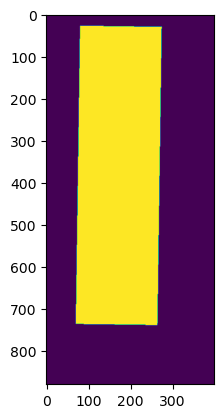

In [294]:
target_mask = Interpolator(Grid(target_lat, target_lon), grid)(np.ones_like(target_lon))
target_mask = ~np.isnan(target_mask)
plt.imshow(target_mask)
plt.show()

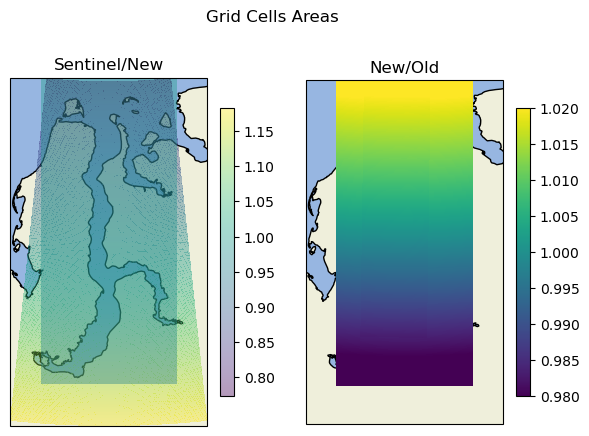

In [298]:
fig, ax = create_cartopy(1,2,figsize=(7,5), lim=False, clon=clon)
plt.suptitle('Grid Cells Areas')

grid = Grid(sen_lat, sen_lon)
f = grid.cell_areas()
mv, dv = f.mean(), (f.max() - f.min())/2
# f[grid.land_mask()] = np.nan
visualize_scalar_field(ax[0], sen_lon, sen_lat, f, vmin=mv-dv, vmax=mv+dv, alpha=0.4, colorbar=True)
ax[0].set_title('Sentinel/New')

grid = Grid(lat, lon)
f = grid.cell_areas()
mv = f.mean()
visualize_scalar_field(ax[0], lon, lat, f, vmin=mv-dv, vmax=mv+dv, alpha=0.4)
# f[grid.land_mask()] = np.nan
f[target_mask] = np.nan
visualize_scalar_field(ax[1], lon, lat, f, colorbar=True, vmin=0.98, vmax=1.02, alpha=1)
t = Grid(target_lat, target_lon).cell_areas()
visualize_scalar_field(ax[1], target_lon, target_lat, t, vmin=0.98, vmax=1.02, alpha=1)

ax[1].set_title('New/Old')
ax[1].set_extent([sen_lon.min(),sen_lon.max(), sen_lat.min(),sen_lat.max()])

plt.show()

In [299]:
corner_lon, corner_lat = np.linspace(71.04, 75.5, 200), np.linspace(73.81, 67.36, 825)
corner_lon, corner_lat = np.meshgrid(corner_lon, corner_lat)
m = ~np.isnan(Interpolator(Grid(corner_lat, corner_lon), grid)(np.ones_like(corner_lon)))

using conserve regrid method


In [303]:
np.save('data3/mask3to1.npy', m)

# Sentinel

пустоты в данных обозначаются: до - 0, после - 0

In [80]:
sentinel_interpolator = Interpolator(Grid(sen_lat, sen_lon), grid)

using conserve regrid method


In [81]:
def get_sentinel(date: date):
    path = f'sentinel1/{date}.png'
    if os.path.exists(path):
    # загрузка данных, маска валидных данных:
        fragment = iio.imread(path)
        hv, hh, fmask = fragment[:,:,0], fragment[:,:,2], (fragment[:,:]>0).all(2)
    # интерполяция с учетом пустот
        hv, hh = sentinel_interpolator(hv), sentinel_interpolator(hh)
        fmask = sentinel_interpolator(fmask)>0.99
        hv[~fmask] = 0
        hh[~fmask] = 0
    else:
        hv = hh = np.zeros_like(mask)
    return hv, hh

In [83]:
# загразка и интерполяция данных
start_date, end_date = date(2014,10,25), date(2023,12,31)
sentinel_raw = [get_sentinel(start_date)]
for i in trange((end_date - start_date).days):
    sentinel_raw.append(get_sentinel(start_date + timedelta(days=i+1)))
# нормировка
sentinel_raw = np.clip(sentinel_raw, 0, 255)/255

  0%|          | 0/3354 [00:00<?, ?it/s]

In [84]:
np.save(f'data3/sentinel-HV-raw_{start_date}_{end_date}.npy', sentinel_raw[:,0])
np.save(f'data3/sentinel-HH-raw_{start_date}_{end_date}.npy', sentinel_raw[:,1])

Фильтрация:

In [221]:
# временное заполнение пропусков персистенсом
sentinel = sentinel_raw.copy()
mean = np.ma.array(sentinel, mask=sentinel==0).mean(0).data
mean[np.isnan(mean)]=0

sentinel[0] += mean*(sentinel[0]==0)
for i in range(1, len(sentinel)):
    sentinel[i] += sentinel[i-1]*(sentinel[i]==0)

In [225]:
valid_idxs = np.arange(sentinel_raw.shape[0])[sentinel_raw.mean((1,2,3))>0]

summer_idxs = valid_idxs[
    np.concatenate([
        np.arange(205,275),
        np.arange(521,617),
        np.arange(893,948),
        np.arange(1181,1249),
        np.arange(1456,1498),
        np.arange(1715,1751),
        np.arange(1971,2000),
        np.arange(2173,2193),
        np.arange(2372,2381)
    ])]
summer = sentinel[summer_idxs].copy()
smean_hv = summer.min(0)[0]
smean_hh = summer.min(0)[1]

winter_idxs = valid_idxs[
    np.concatenate([
        np.arange(30,185),
        np.arange(295,501),
        np.arange(647,863),
        np.arange(978,1151),
        np.arange(1279,1426),
        np.arange(1538,1685),
        np.arange(1781,1941),
        np.arange(2030,2143),
        np.arange(2223,2342)
    ])]
wmean = sentinel[winter_idxs].mean(0)[0]

In [226]:
def prod(a, b, keepdims=False):
    return (a*b*(~mask)).mean((-2,-1), keepdims=keepdims)

def proj(v, basis):
    w = v.copy()
    for b in basis:
        w -= prod(v,b,True)*b
    return w
    
def gram_shmidt(vectors, orths, minnorm=1e-6):
    vectors = list(orths) + list(vectors)
    v = vectors[0]
    basis = [v/np.sqrt(prod(v,v))]
    for v in vectors[1:]:
        w = proj(v, np.stack(basis))
        n = prod(w,w)
        if (n > minnorm).any():
            basis.append(w/np.sqrt(n))
    return np.stack(basis[len(orths):])

def filter(v, augments):
    w = proj(v, tqdm(augments, leave=True))
    w[v>0] = np.clip(w[v>0], v[v>0].min(), v.max())
    return w

In [228]:
sentinel[valid_idxs] = np.stack(( 
    filter(sentinel[:,0][valid_idxs], gram_shmidt(summer[:,0] - smean_hv, [smean_hv, wmean])),
    filter(sentinel[:,1][valid_idxs], gram_shmidt(summer[:,1] - smean_hh, [smean_hh, wmean]))
), 1) 
sentinel *= sentinel_raw > 0

  0%|          | 0/409 [00:00<?, ?it/s]

  0%|          | 0/424 [00:00<?, ?it/s]

In [251]:
def polarvideo(HV, HH):
    HH *= HV>0

    mhh = (HH ** (1.1)) * 0.32
    mhv = (HV ** (1.1) + 0.02/(0.1-0.02)) * (0.1-0.02)
    res = ((1 - 2 * mhh) * mhv + 2 * mhh) * mhv;
    mix = np.clip((res/0.06)**(1/1.1), 0, 1)
    
    return np.stack([HV, mix, HH, np.repeat((1-mask)[None], len(HV), 0)], -1)

In [243]:
np.save(f'data3/sentinel-HV_{start_date}_{end_date}.npy', sentinel[:,0])
np.save(f'data3/sentinel-HH_{start_date}_{end_date}.npy', sentinel[:,1])

In [272]:
video(lon, lat, [
    polarvideo(sentinel[:,0][valid_idxs], sentinel[:,1][valid_idxs]), 
    polarvideo(sentinel_raw[:,0][valid_idxs],sentinel_raw[:,1][valid_idxs])
], ['processed', 'raw'], 'SAR')

  0%|          | 0/2437 [00:00<?, ?it/s]

# AMSR

пустоты в данных обозначаются: до - 127, после - 0

In [280]:
ds = nc.Dataset('amsr/netcdf/coordinates_npstere_1km_arctic.nc')
amsr_grid = Grid(np.array(ds.variables['lat'])[::-1], np.array(ds.variables['lon'])[::-1])
amsr_interpolator = Interpolator(amsr_grid, grid)

using conserve regrid method


In [281]:
def get_amsr(date: date):
    path = f'amsr/netcdf/Arctic/{date.year}/sic_modis-aqua_amsr2-gcom-w1_merged_nh_1000m_{date.strftime("%Y%m%d")}.nc'
    if os.path.exists(path):
    # загрузка данных
        fragment = np.array(nc.Dataset(path).variables['sic_merged'])
    # определение пустот, маска валидных данных:
        fmask = fragment < 127
    # интерполяция с учетом пустот
        fragment = amsr_interpolator(fragment)
        fmask = amsr_interpolator(fmask)>0.99
        fragment[~fmask] = 0
    else:
        fragment = np.zeros_like(mask)
    return fragment

In [283]:
start_date, end_date = date(2017,10,1), date(2023,12,31)
amsr = [get_amsr(start_date)]
for i in trange((end_date - start_date).days):
    amsr.append(get_amsr(start_date + timedelta(days=i+1)))
# нормировка
amsr = np.clip(np.stack(amsr), 0, 100)/100 

  0%|          | 0/2282 [00:00<?, ?it/s]

In [284]:
np.save(f'data3/amsr_{start_date}_{end_date}.npy', amsr)

# GLORYS

пустоты в данных обозначаются: до - индивидуальная маска, после - 0

In [3]:
glo1 = nc.Dataset(
    'glorys/cmems_mod_glo_phy_my_0.083deg_P1D-m_multi-vars_61.33E-90.00E_64.83N-75.58N_0.49m_2015-09-01-2021-06-30.nc')
glo2 = nc.Dataset(
    'glorys/cmems_mod_glo_phy_myint_0.083deg_P1D-m_multi-vars_61.33E-90.00E_64.83N-75.58N_0.49m_2021-07-01-2023-10-24.nc')

In [4]:
glorys_grid = Grid(*[x.T for x in np.meshgrid(glo1.variables['latitude'], glo1.variables['longitude'])])
glorys_interpolator = Interpolator(glorys_grid, grid)

using bilinear regrid method


In [5]:
def get_glorys(nc, idx):
    # загрузка данных
    fragment = np.squeeze(nc[idx])
    # определение пустот, маска валидных данных:
    fmask = ~fragment.mask
    # интерполяция с учетом пустот
    fragment[~fmask] = 0
    fragment = glorys_interpolator(fragment)
    fmask = glorys_interpolator(fmask)>0.99
    fragment[~fmask] = 0
    return fragment

In [6]:
start_date, end_date = date(2015,9,1), date(2023,10,24)
glorys = {}
for feature in ['bottomT','mlotst','so','thetao','zos','uo','vo']: # 'siconc','sithick','usi','vsi'
    channel = []
    bar = trange((end_date - start_date).days + 1)
    for i in range((start_date - date(2015,9,1)).days, (date(2021,6,30) - date(2015,9,1)).days + 1):
        channel.append(get_glorys(glo1.variables[feature], i))    
        bar.update()
    for i in range(0, (end_date - date(2021,7,1)).days + 1):
        channel.append(get_glorys(glo2.variables[feature], i))  
        bar.update()
    bar.close()
    glorys[feature] = np.stack(channel)
# нормировка
for feature in ['bottomT','mlotst','so','thetao']:
    m = glorys[feature].max()
    print('max', feature, m)
    glorys[feature] /= m
for feature in ['zos']:
    fmask = glorys[feature]==0
    m = glorys[feature][~fmask].mean()
    print('mean', feature, m)
    glorys[feature][~fmask] -= m
    glorys[feature][fmask] = 0

  0%|          | 0/2976 [00:00<?, ?it/s]

  0%|          | 0/2976 [00:00<?, ?it/s]

  0%|          | 0/2976 [00:00<?, ?it/s]

  0%|          | 0/2976 [00:00<?, ?it/s]

  0%|          | 0/2976 [00:00<?, ?it/s]

  0%|          | 0/2976 [00:00<?, ?it/s]

  0%|          | 0/2976 [00:00<?, ?it/s]

max bottomT 14.573894529942965
max mlotst 50.38781726019543
max so 39.49769198527525
max thetao 14.602806560696626
mean zos -0.368303548846162


In [7]:
for feature in glorys:
    np.save(f'data3/glorys-{feature}_{start_date}_{end_date}.npy', glorys[feature])

# Meteostations

In [260]:
# задание координат
coords = {
    # 23552: (64.92, 77.82),
    23242: (67.68, 72.88),
    20967: (70.17, 72.52),
    20864: (71.48, 71.82),
    20667: (73.33, 70.05),
    23345: (66.63, 72.93),
    23340: (66.80, 70.83),
    23334: (66.87, 68.13),
    23235: (67.64, 67.56),
    23339: (66.03, 68.68),
    23445: (65.47, 72.67),
    23256: (67.47, 78.73),
    23058: (69.08, 76.85),
    23358: (66.10, 76.78),
    23453: (65.95, 78.40),
    20665: (73.50, 76.00),
    20674: (73.52, 80.40),
    23032: (69.71, 66.80),
    23029: (69.25, 64.93),
    # 23330: (66.53, 66.67),
    # 23542: (64.68, 72.36),
    20978: (70.08, 83.17),
    20871: (71.87, 82.70),
    20471: (75.95, 82.95),
    20353: (76.95, 68.55),
    23029: (69.25, 64.93),
    20963: (70.88, 78.47),
}

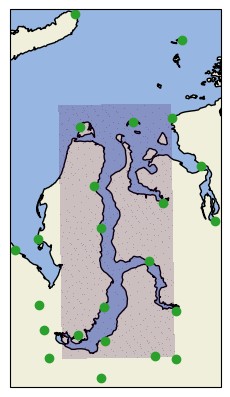

In [261]:
fig, ax = create_cartopy()
ax.set_extent([sen_lon.min()-2,sen_lon.max()+1.5, sen_lat.min(),sen_lat.max()+3])
visualize_scalar_field(ax, lon, lat, 0*mask, alpha=0.2)
for id in coords: plt.scatter(coords[id][1], coords[id][0], c='tab:green', transform=ccrs.PlateCarree())

In [ ]:
# скачивание данных:
start_date, end_date = date(2014,1,1), date(2023,12,31)
meteostations = {}
bar = trange(len(coords)*len([d for d in 
    rrule(MONTHLY, dtstart=date(start_date.year, start_date.month, 1), until=end_date)]))
for id in coords:
    meteostation = []
    for date_i in rrule(MONTHLY, dtstart=date(start_date.year, start_date.month, 1), until=end_date):
        url = f'http://www.pogodaiklimat.ru/weather.php?id={id}' + \
              f'&bday=1&fday={calendar.monthrange(date_i.year, date_i.month)[1]}' + \
              f'&amonth={date_i.month}&ayear={date_i.year}&bot=2'
        tables = [df.loc[1:] for df in pd.read_html(url)]
    # cкалярные велечины
        data = tables[1][[5,7,11]].apply(
            lambda c: c.astype(str).str.extract('(\d+)', expand=False).astype(float))
        data = data.rename({5:'T',7:'f',11:'P'}, axis=1)
    # векторные
        wspeed = tables[1][1].apply(
            lambda s: np.float32(str(s).split()[0].split('-')[0].split('{')[0].split('/')[0] or 0))
        data['u'] = wspeed*tables[1][0].apply(
            lambda s: np.nan if pd.isna(s) else (1 if 'В' in s else (-1 if 'З' in s else 0))/np.sqrt(len(s)))
        data['v'] = wspeed*tables[1][0].apply(
            lambda s: np.nan if pd.isna(s) else (1 if 'С' in s else (-1 if 'Ю' in s else 0))/np.sqrt(len(s)))
    # агрегация по времени
        mmask = tables[0][1].apply(lambda s: int(s.split('.')[1]) == date_i.month)
        data = data[mmask]
        data['date'] = pd.to_datetime(tables[0][1][mmask]+f'.{date_i.year}', format="%d.%m.%Y")
        data = data.groupby('date').mean()
    # конкатенация
        meteostation.append(data)
        bar.update()
    meteostations[id] = pd.concat(meteostation)
bar.close()

In [274]:
def get_meteo(date: date):
    coord, fields = [], []
    for id in coords:
        index = date.strftime("%Y-%m-%d")
        if index in meteostations[id].index:
            coord.append(coords[id])
            field = np.array(meteostations[id].loc[index])
            if len(field.shape)>1:
                field = field[0]
            fields.append(field)
    coord, fields = np.array(coord), np.array(fields)
    # интерполяция
    interpolated_fields = []
    if len(fields):
        for i in range(5):
            field = fields[:,i]
            interpolator = RBFInterpolator(coord[~np.isnan(field)], field[~np.isnan(field)])
            field = interpolator(np.stack((lat.ravel(),lon.ravel()),1)).reshape(*mask.shape)
            interpolated_fields.append(field)
        fields = np.stack(interpolated_fields)
    else:
        fields = np.zeros(5,*mask.shape)
    return fields

In [278]:
meteo = [get_meteo(start_date)]
for i in trange((end_date - start_date).days):
    meteo.append(get_meteo(start_date + timedelta(days=i+1)))
meteo = np.stack(meteo)
# нормировка
meteo[:,0] /= 50
meteo[:,1] = np.clip(meteo[:,1],0,100)/100
meteo[:,2] = meteo[:,2]/1013.25-1
meteo[:,[3,4]] /= 15

  0%|          | 0/3651 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [279]:
np.save(f'data3/meteo-T_{start_date}_{end_date}.npy', meteo[:,0])
np.save(f'data3/meteo-f_{start_date}_{end_date}.npy', meteo[:,1])
np.save(f'data3/meteo-P_{start_date}_{end_date}.npy', meteo[:,2])
np.save(f'data3/meteo-u_{start_date}_{end_date}.npy', meteo[:,3])
np.save(f'data3/meteo-v_{start_date}_{end_date}.npy', meteo[:,4])

# Exploration

гистрограммы

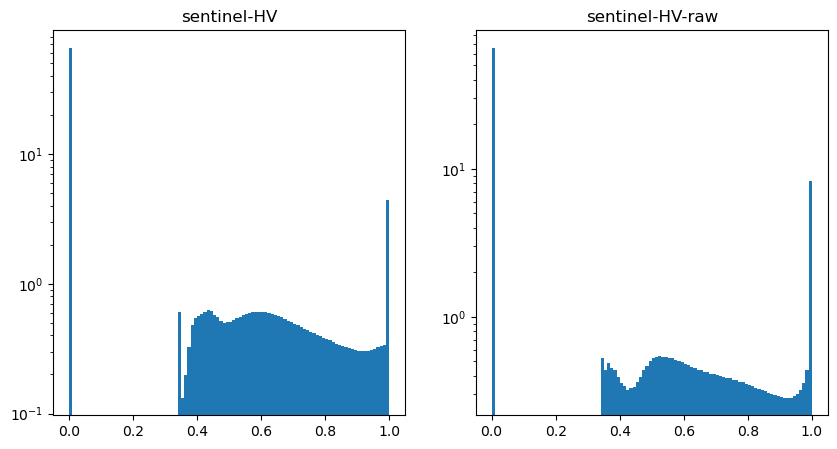

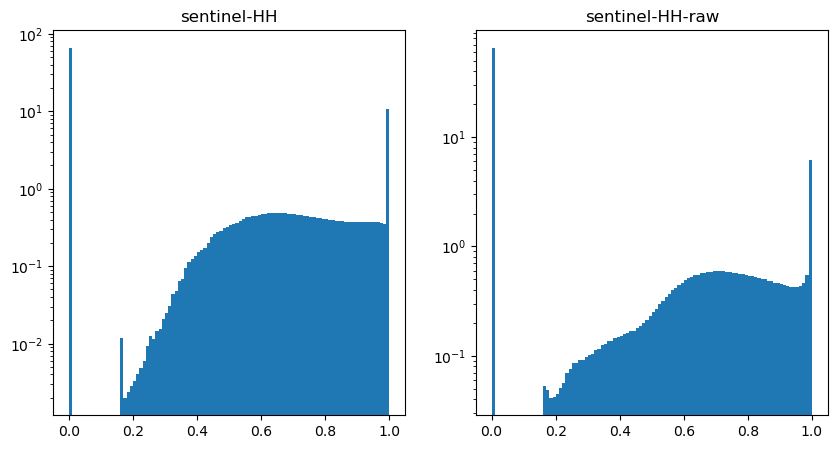

In [273]:
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.hist(sentinel[:,0].ravel(), bins=100, density=True)
plt.yscale('log')
plt.title('sentinel-HV')
plt.subplot(122)
plt.hist(sentinel_raw[:,0].ravel(), bins=100, density=True)
plt.yscale('log')
plt.title('sentinel-HV-raw')
plt.show()

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.hist(sentinel[:,1].ravel(), bins=100, density=True)
plt.yscale('log')
plt.title('sentinel-HH')
plt.subplot(122)
plt.hist(sentinel_raw[:,1].ravel(), bins=100, density=True)
plt.yscale('log')
plt.title('sentinel-HH-raw')
plt.show()

In [ ]:
plt.hist(amsr.ravel(), bins=100, density=True)
plt.yscale('log')
plt.title('amsr')
plt.show()

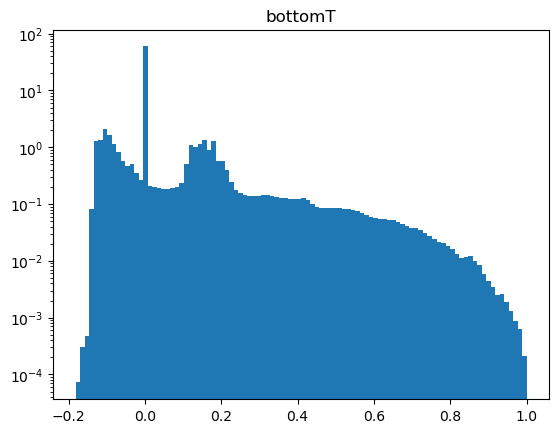

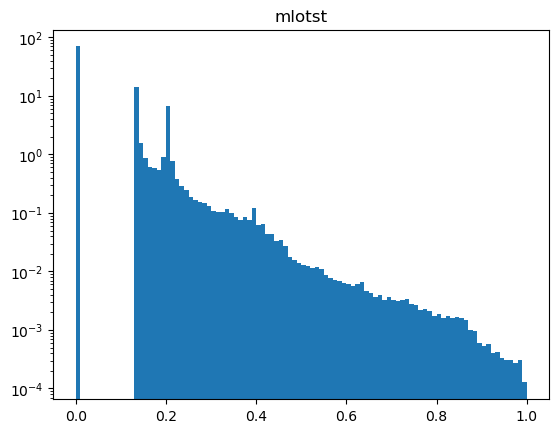

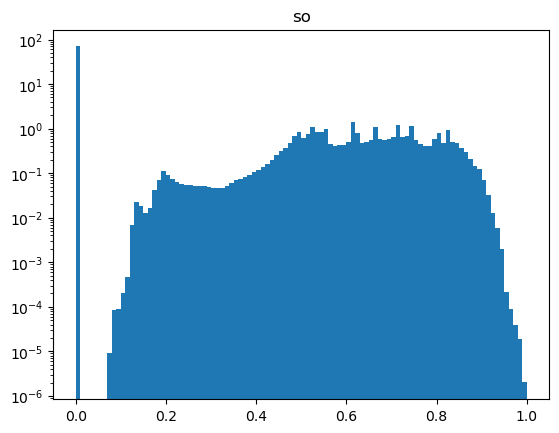

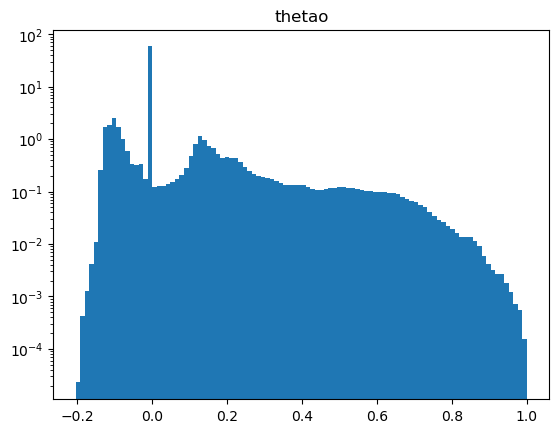

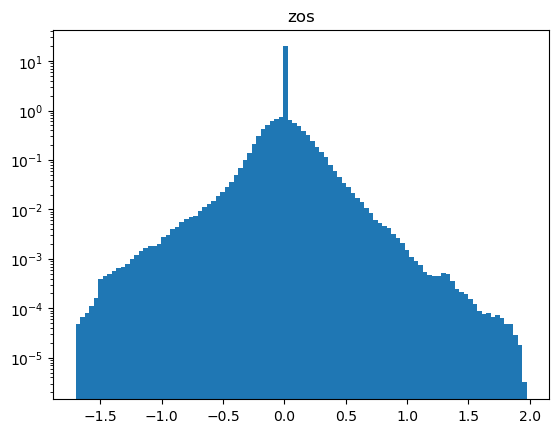

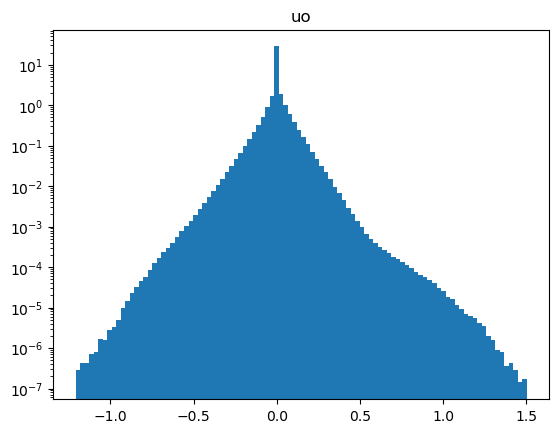

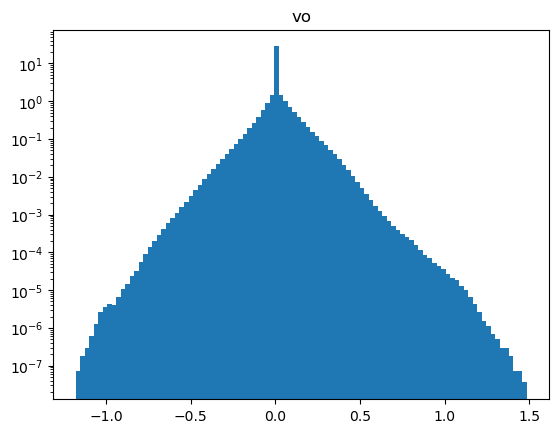

In [8]:
for feature in glorys:
    plt.hist(glorys[feature].ravel(), bins=100, density=True)
    plt.yscale('log')
    plt.title(feature)
    plt.show()

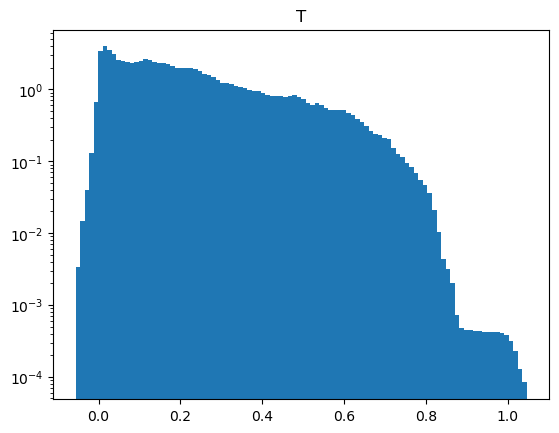

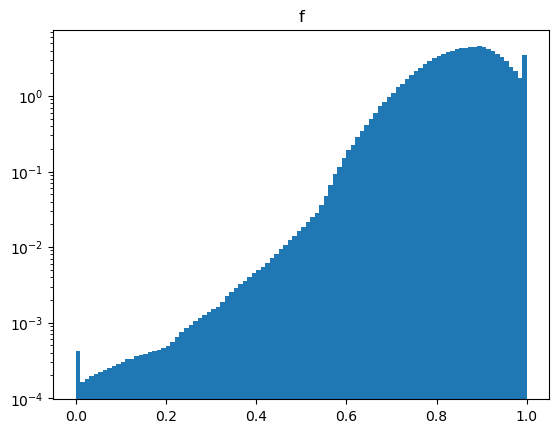

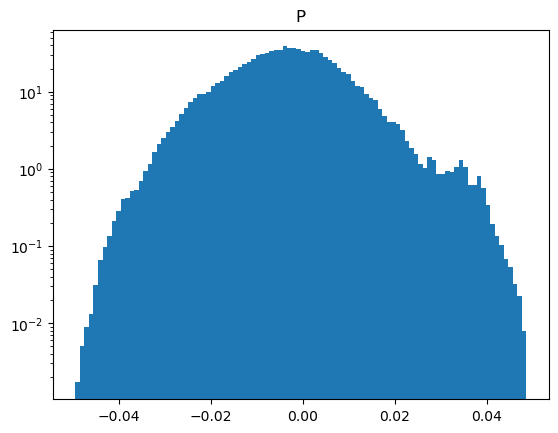

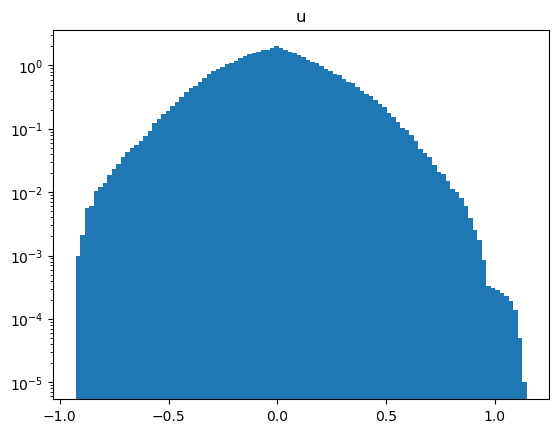

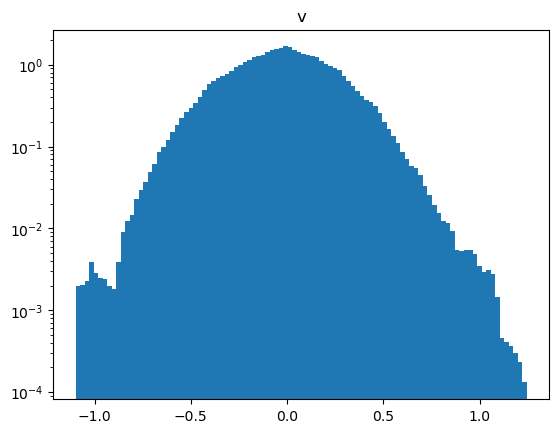

In [661]:
for i, t in zip(range(5), ['T','f','P','u','v']):
    plt.hist(meteo[:,i].ravel(), bins=100, density=True)
    plt.yscale('log')
    plt.title(t)
    plt.show()

графики среднего от времени

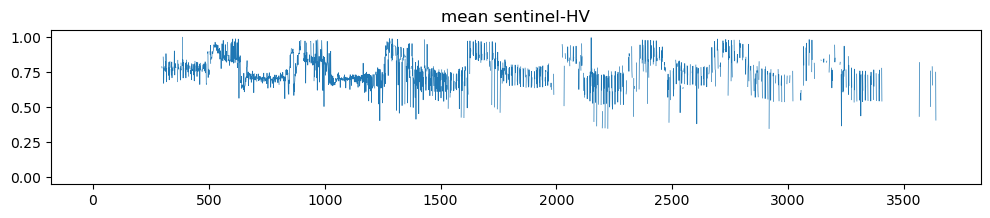

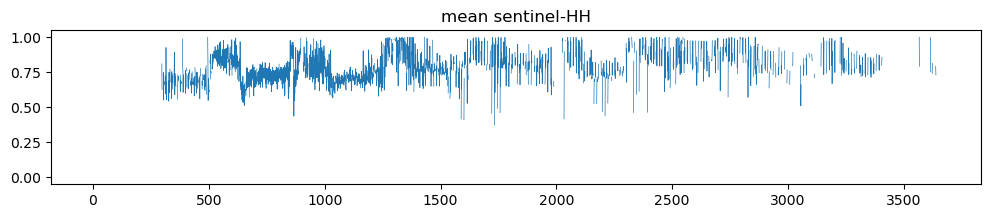

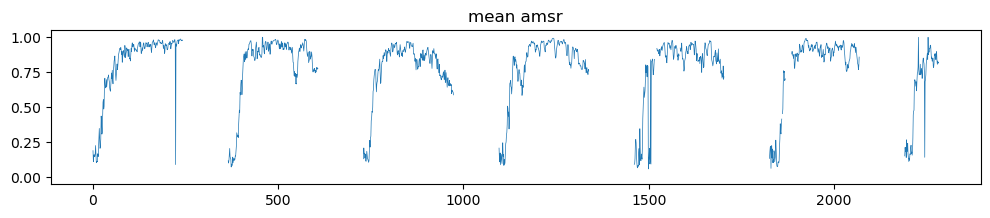

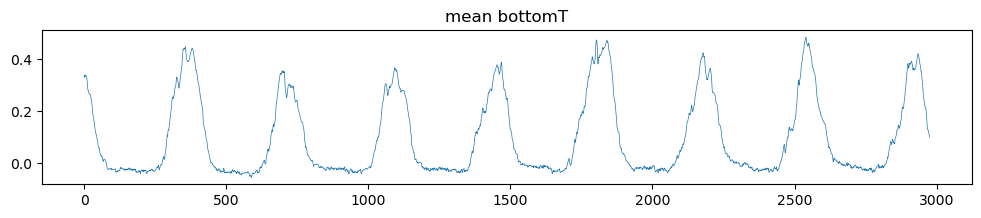

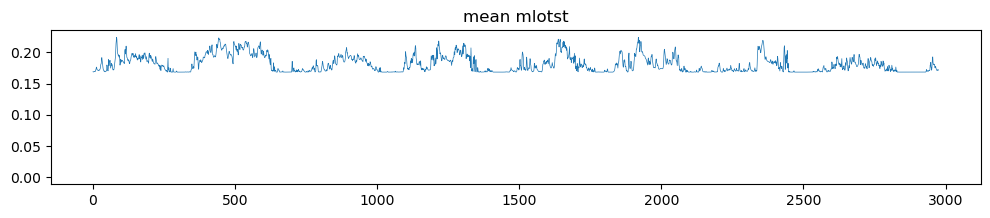

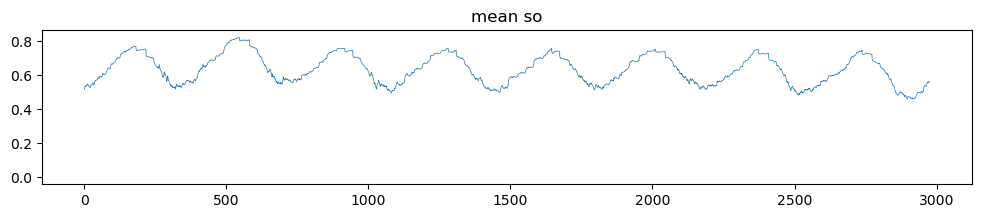

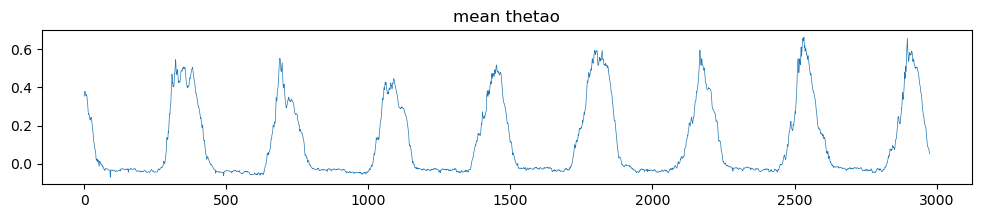

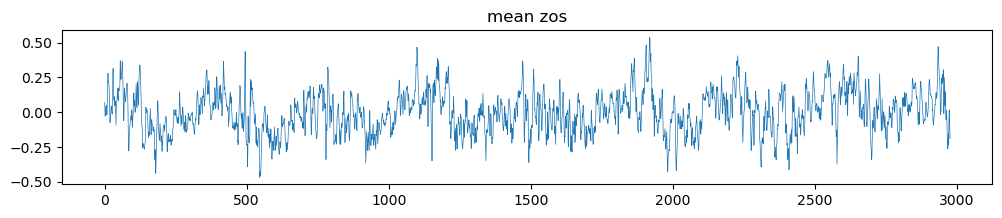

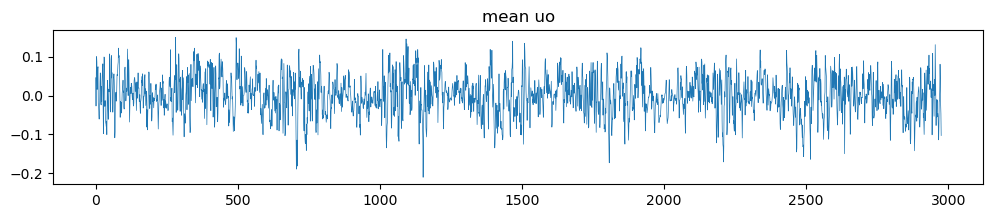

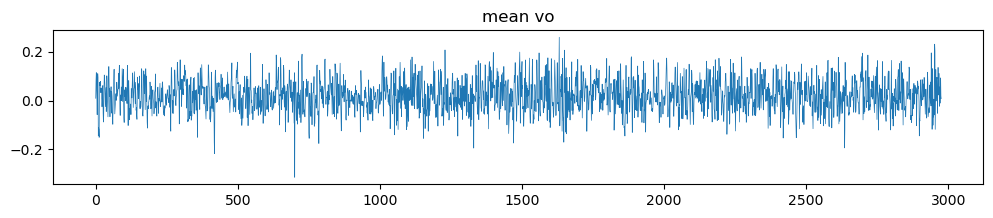

In [14]:
def plot_time(ar, name):
    plt.figure(figsize=(12,2))
    plt.plot(np.ma.array(ar, mask=ar==0).mean((1,2)), lw=0.5)
    plt.plot(0,0)
    plt.title(f'mean {name}')
    plt.show()

plot_time(sentinel[0], 'sentinel-HV')
plot_time(sentinel[1], 'sentinel-HH')
plot_time(amsr, 'amsr')
for feature in glorys:
    plot_time(glorys[feature], feature)

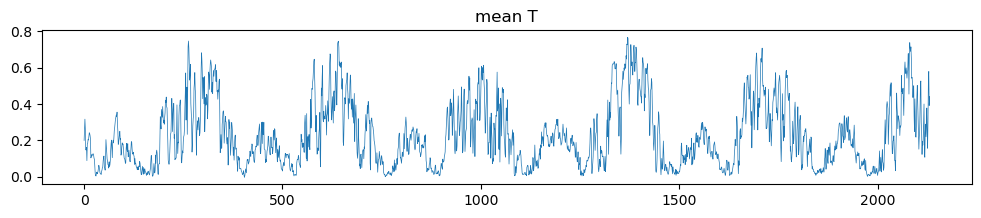

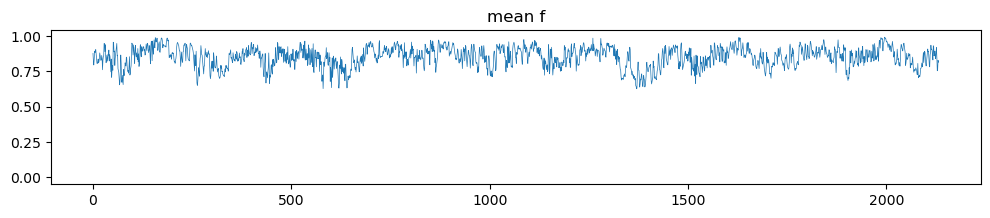

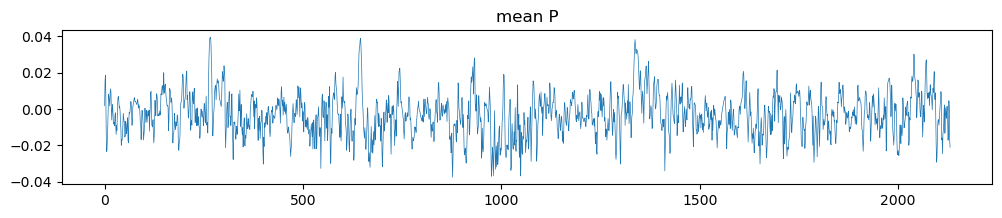

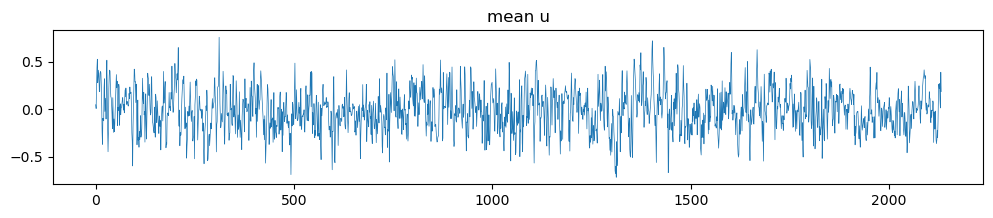

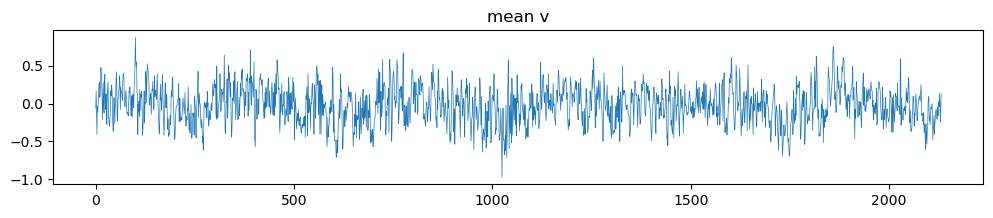

In [662]:
for i, t in zip(range(5), ['T','f','P','u','v']):
    plot_time(meteo[:,i], t)